In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import datetime
import os

In [52]:
def plot_all(file: str):
    """Plots all the data from the given file (HISTORMs)

    Args:
        file (str): file path
    """
    df = pd.read_excel(file)
    df = df.dropna()
    HISTORM_list = df['Name'].drop_duplicates().tolist()
    
    for HISTORM in HISTORM_list:
        if HISTORM not in [
            'HI60', 'HI10', 'HI50', 'HI20', 'HI30', 'HI41', 'HI70', 'HI21',
            'HI51', 'HI80', 'HI71', 'HI40', 'HI61', 'HI31', 'HI81'
        ]:
            pass
        else:
            HI = df.loc[df['Name'] == HISTORM]

            plt.figure(figsize=(16, 9), facecolor='white')
            plt.title(f'{HISTORM}')
            plt.plot(HI['t_stamp'], HI['DeltaTemp'],
                     label=f'Holtec/Casks/{HISTORM}/Delta Temp')
            plt.plot(HI['t_stamp'], HI['EnvAvg'],
                     label=f'Holtec/Environment/TIA/Value')
            plt.plot(HI['t_stamp'], HI['CaskAvg'],
                     label=f'Holtec/Casks/{HISTORM}/Average Temp', color='grey')
            plt.legend()
            plt.grid(alpha=0.6, linestyle='--')
            plt.xlabel('Data')

            # Set xticks to every day at 00:00
            ax = plt.gca()
            ax.xaxis.set_major_locator(mdates.DayLocator(
                interval=1))  # set xticks to every day
            ax.xaxis.set_major_formatter(mdates.DateFormatter(
                '%d/%m/%y %H:%M'))  # format xticks as 'day/month/year'

            start_date = datetime.datetime(df['t_stamp'].dt.year.max(
            ), df['t_stamp'].dt.month.max(), df['t_stamp'].dt.day.min())
            end_date = datetime.datetime(df['t_stamp'].dt.year.max(
            ), df['t_stamp'].dt.month.max(), df['t_stamp'].dt.day.max(), 12, 00, 00)
            # set x-axis limits to first and last day
            ax.set_xlim([start_date, end_date])

            plt.xticks(rotation=90)
            plt.ylabel('Temperatura [°C]')
            plt.ylim(0, 75)

            # Save the plot as a high-quality image
            plt.tight_layout()

            # Check if the directory exists and create it if it doesn't
            if not os.path.exists('plots'):
                os.makedirs('plots')

            plt.savefig(f'plots/{HISTORM}.png', dpi=300, format='png')

            plt.show()

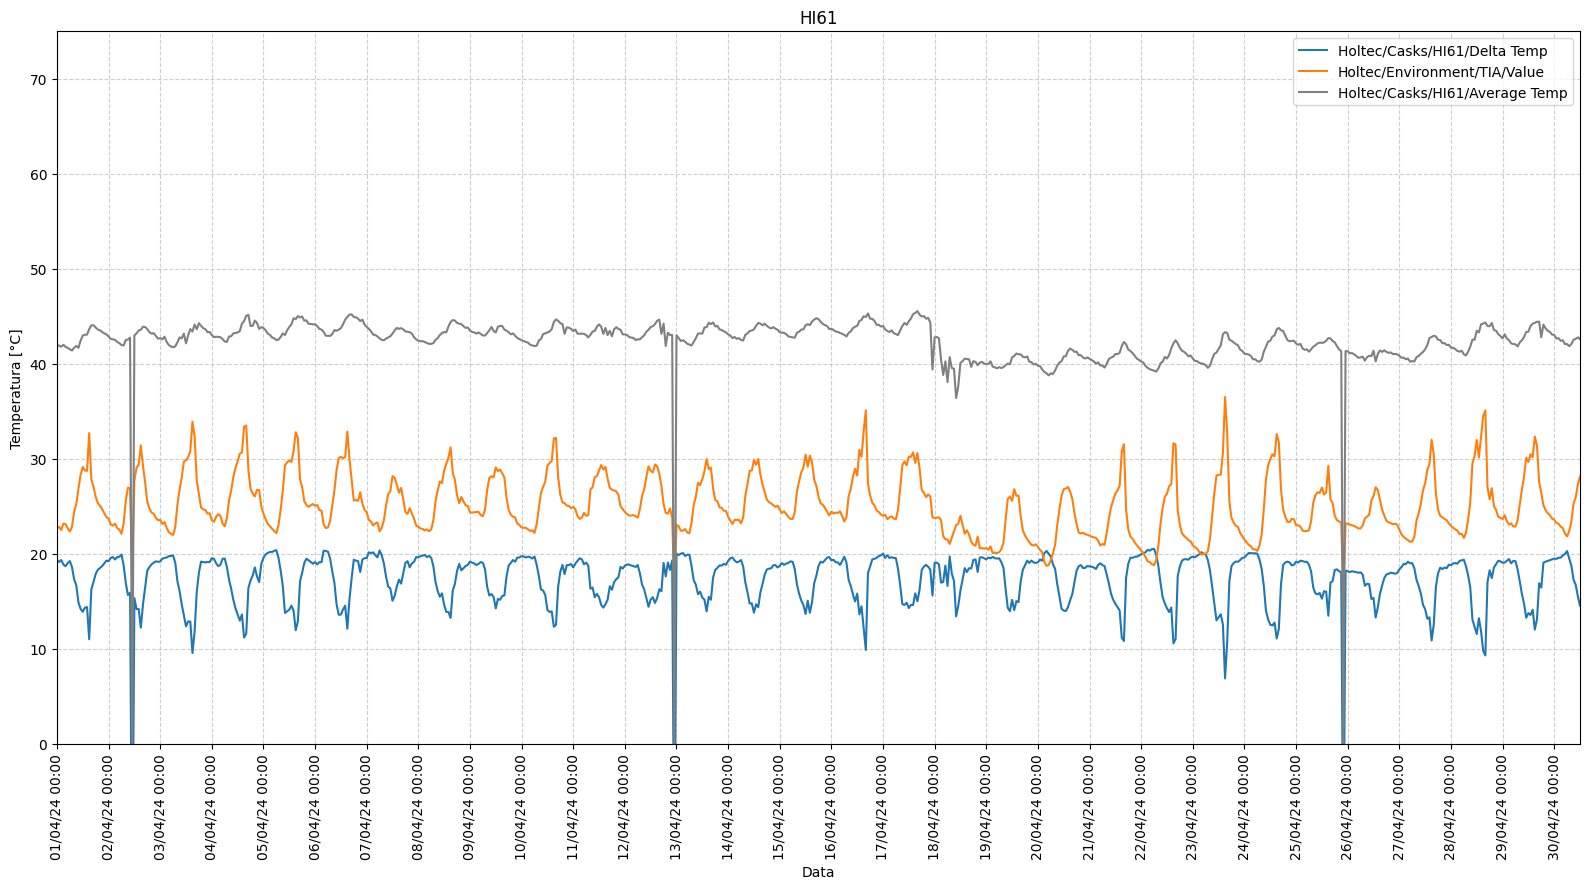

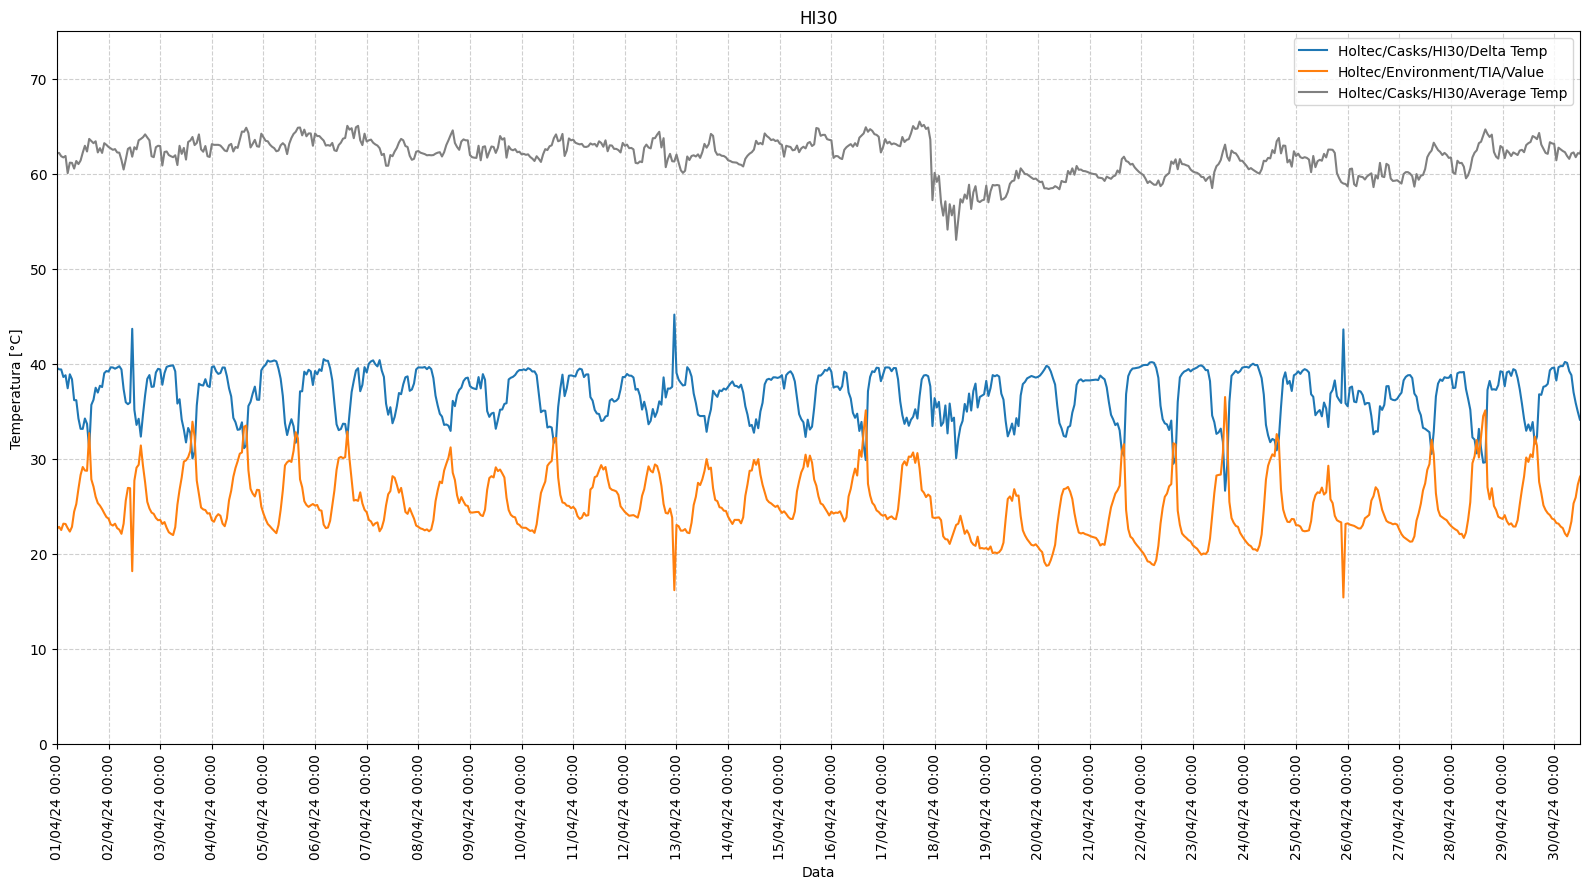

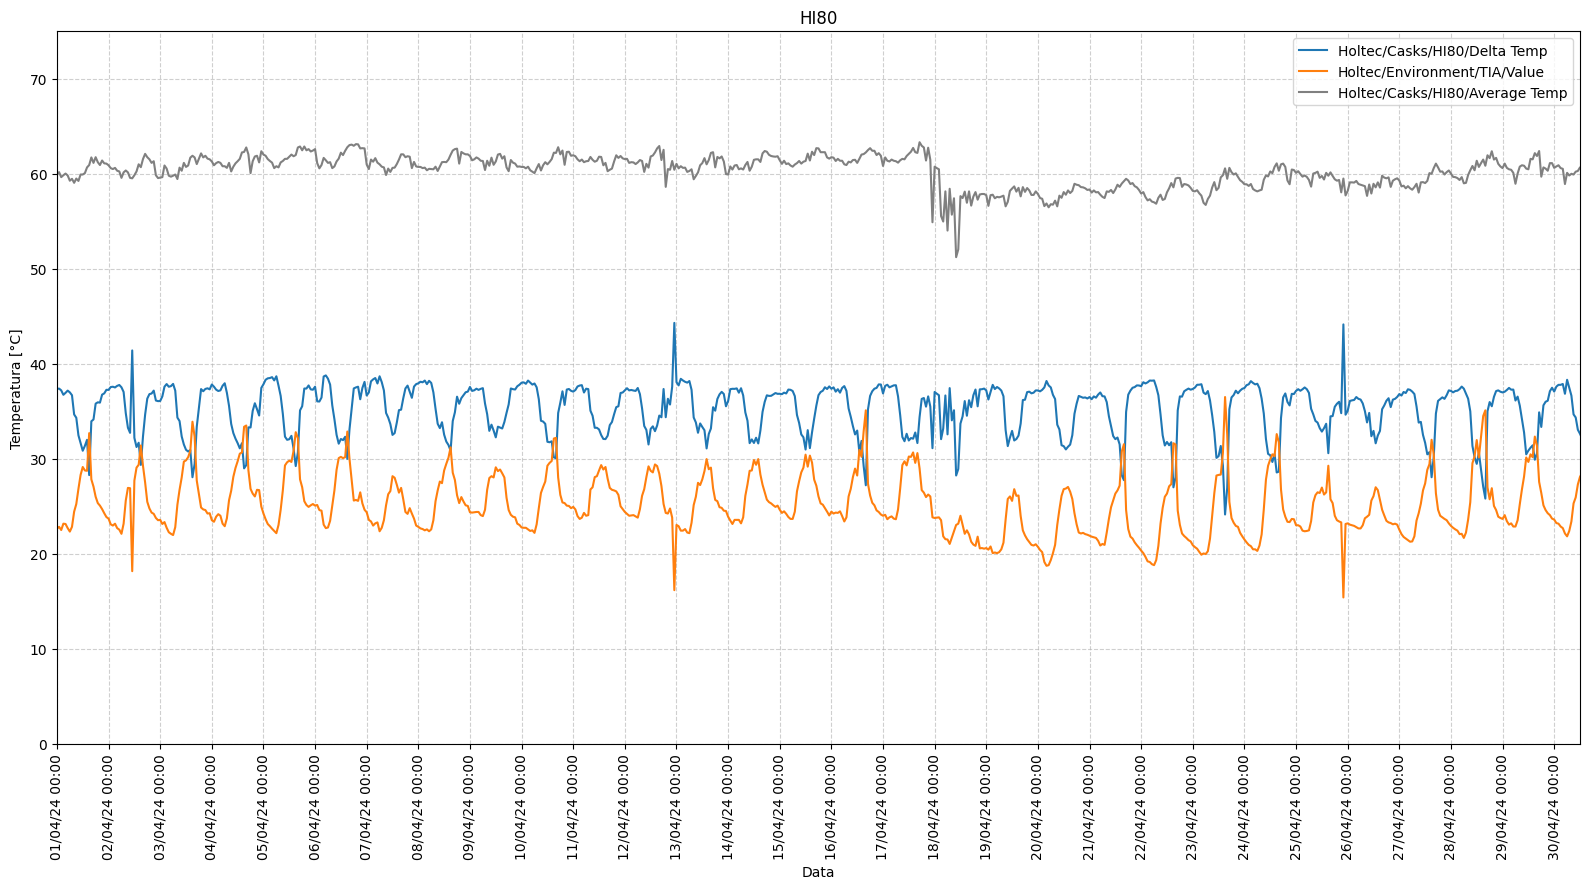

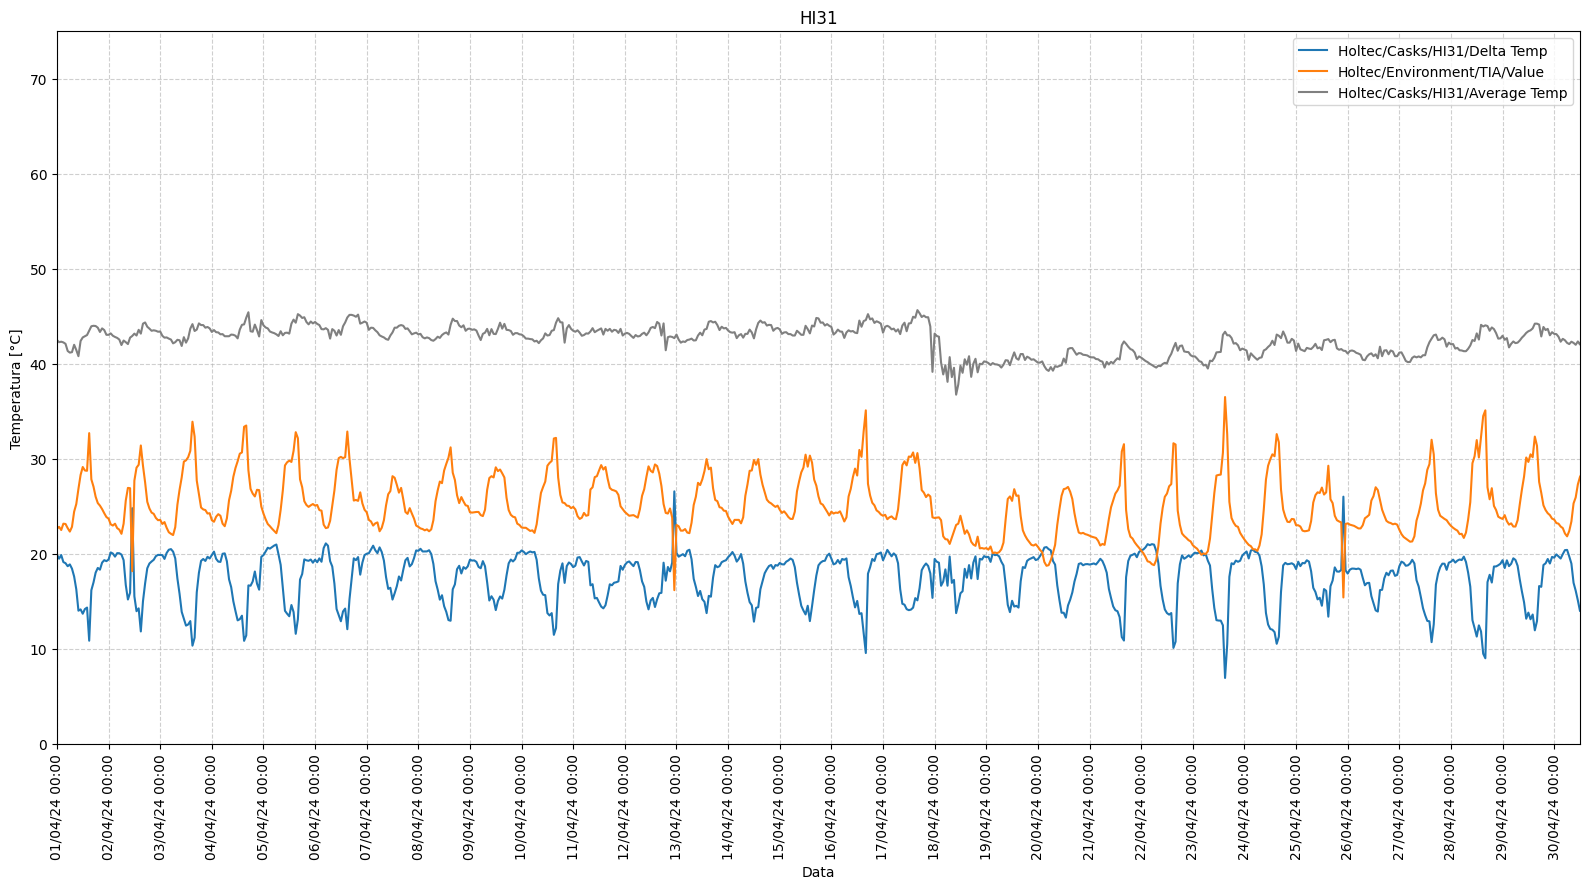

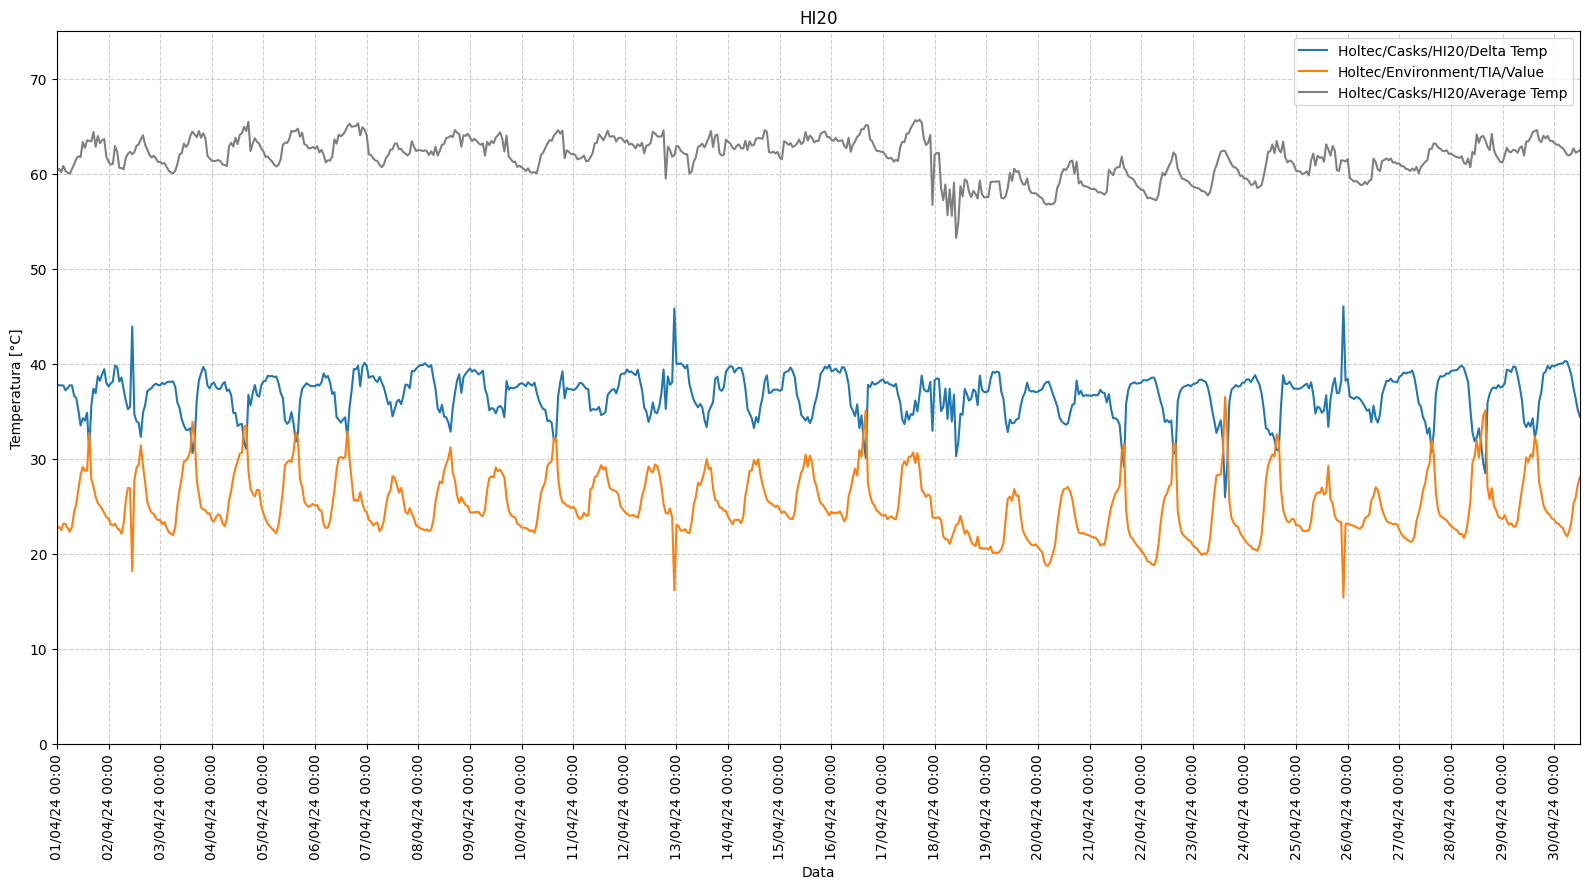

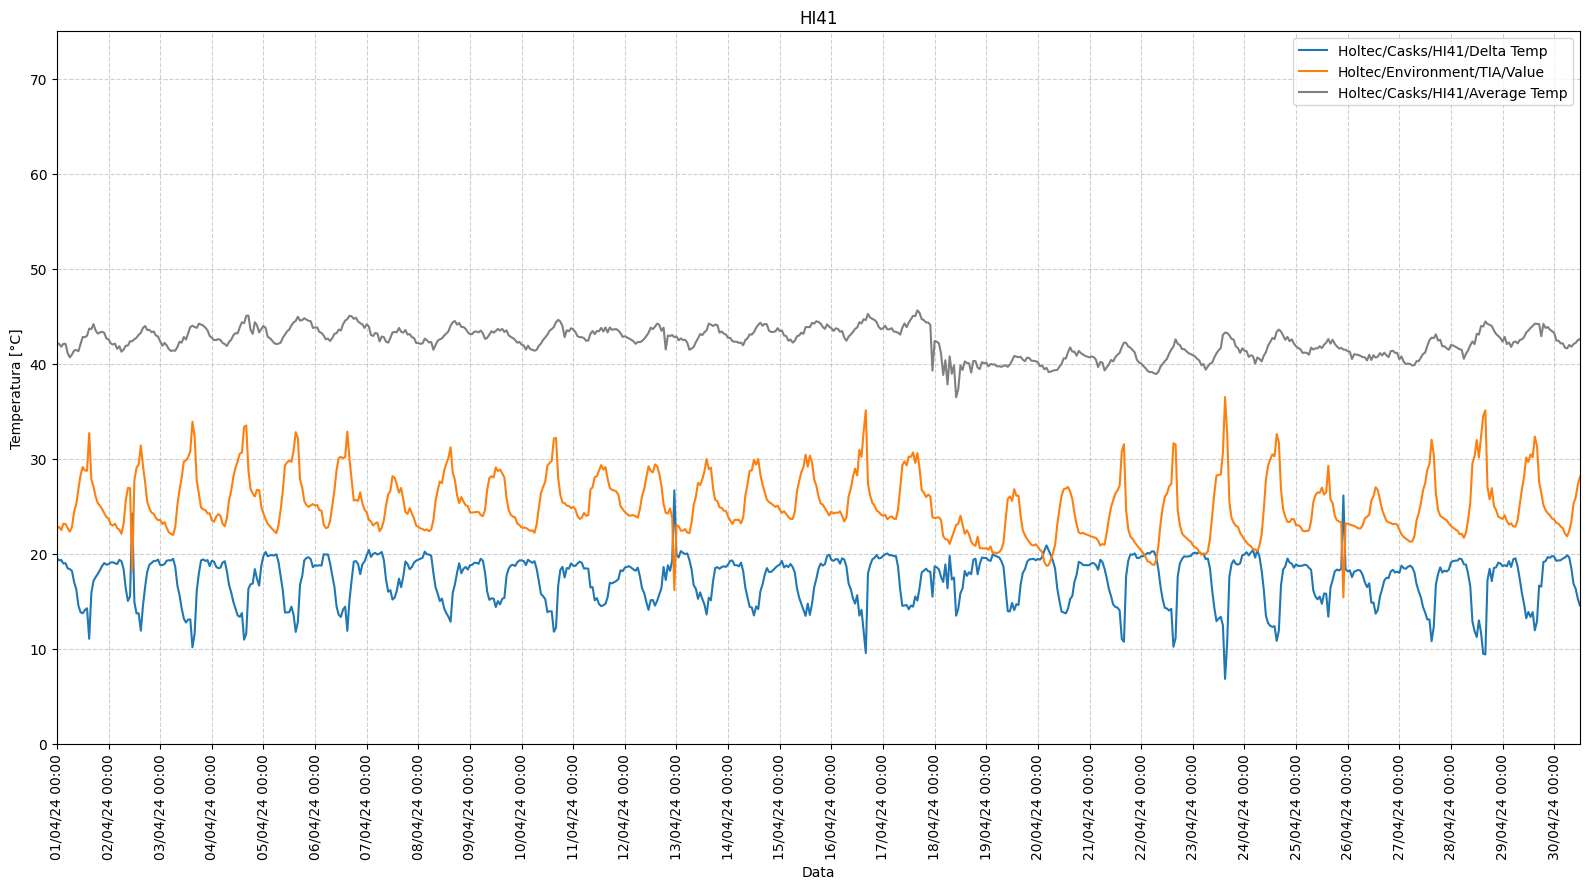

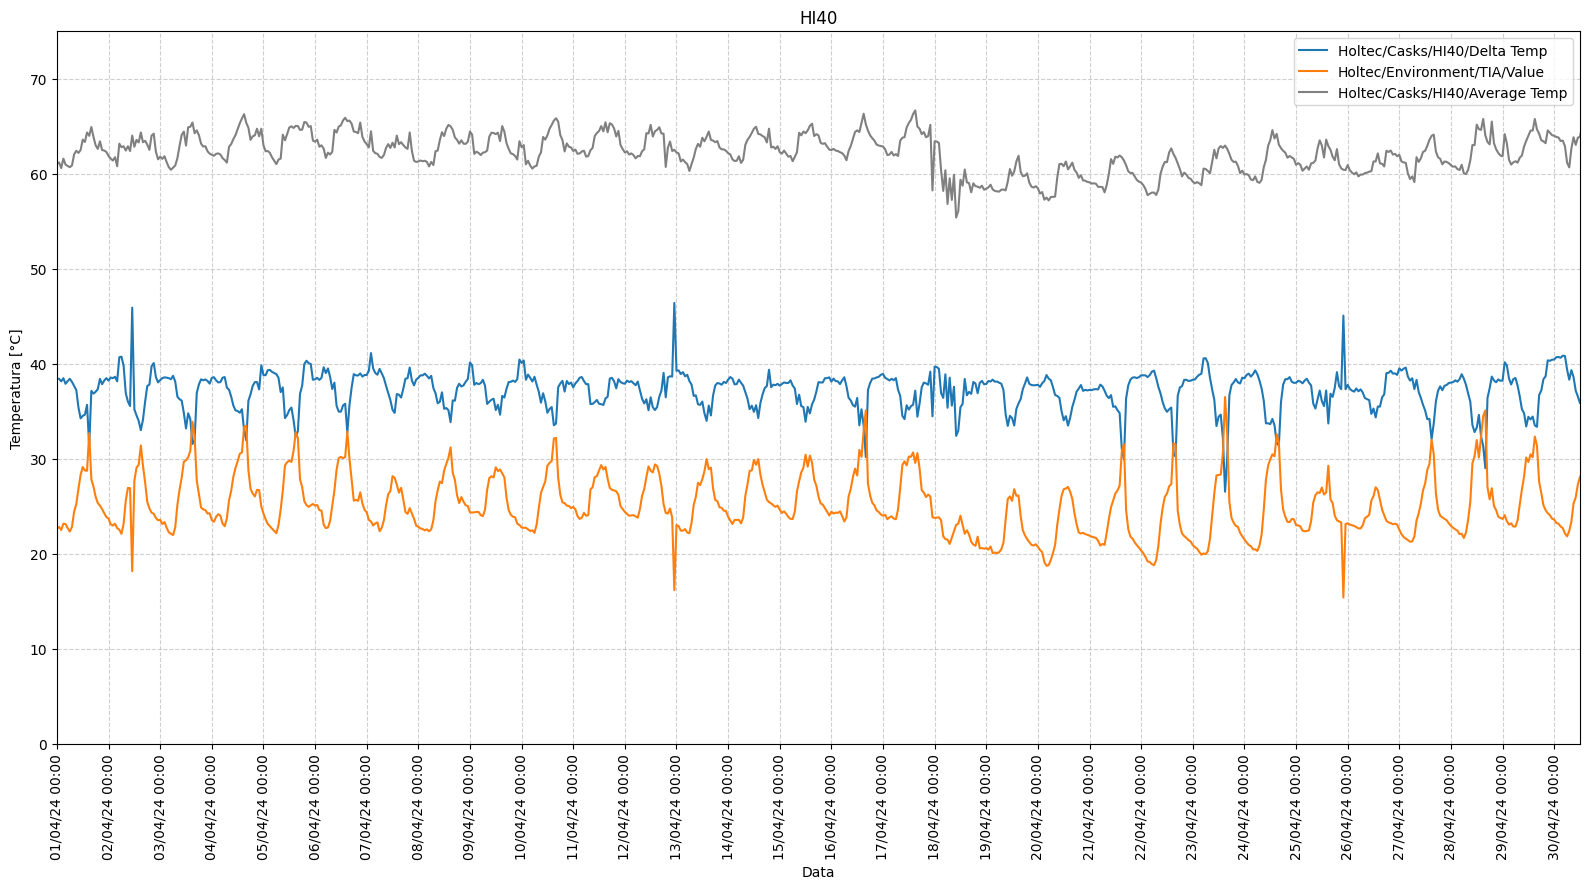

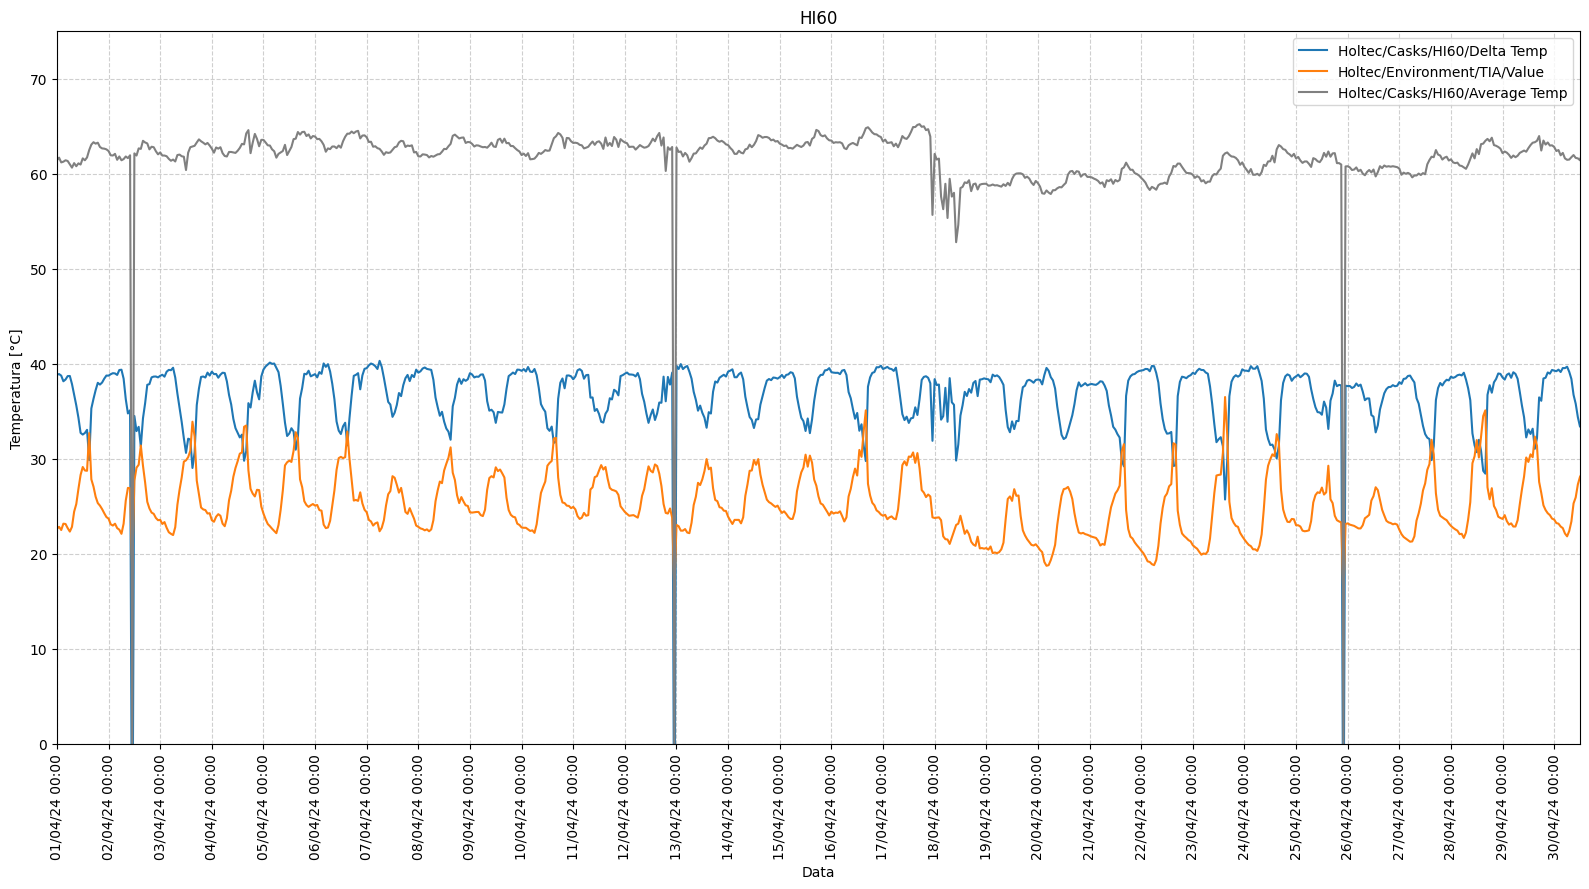

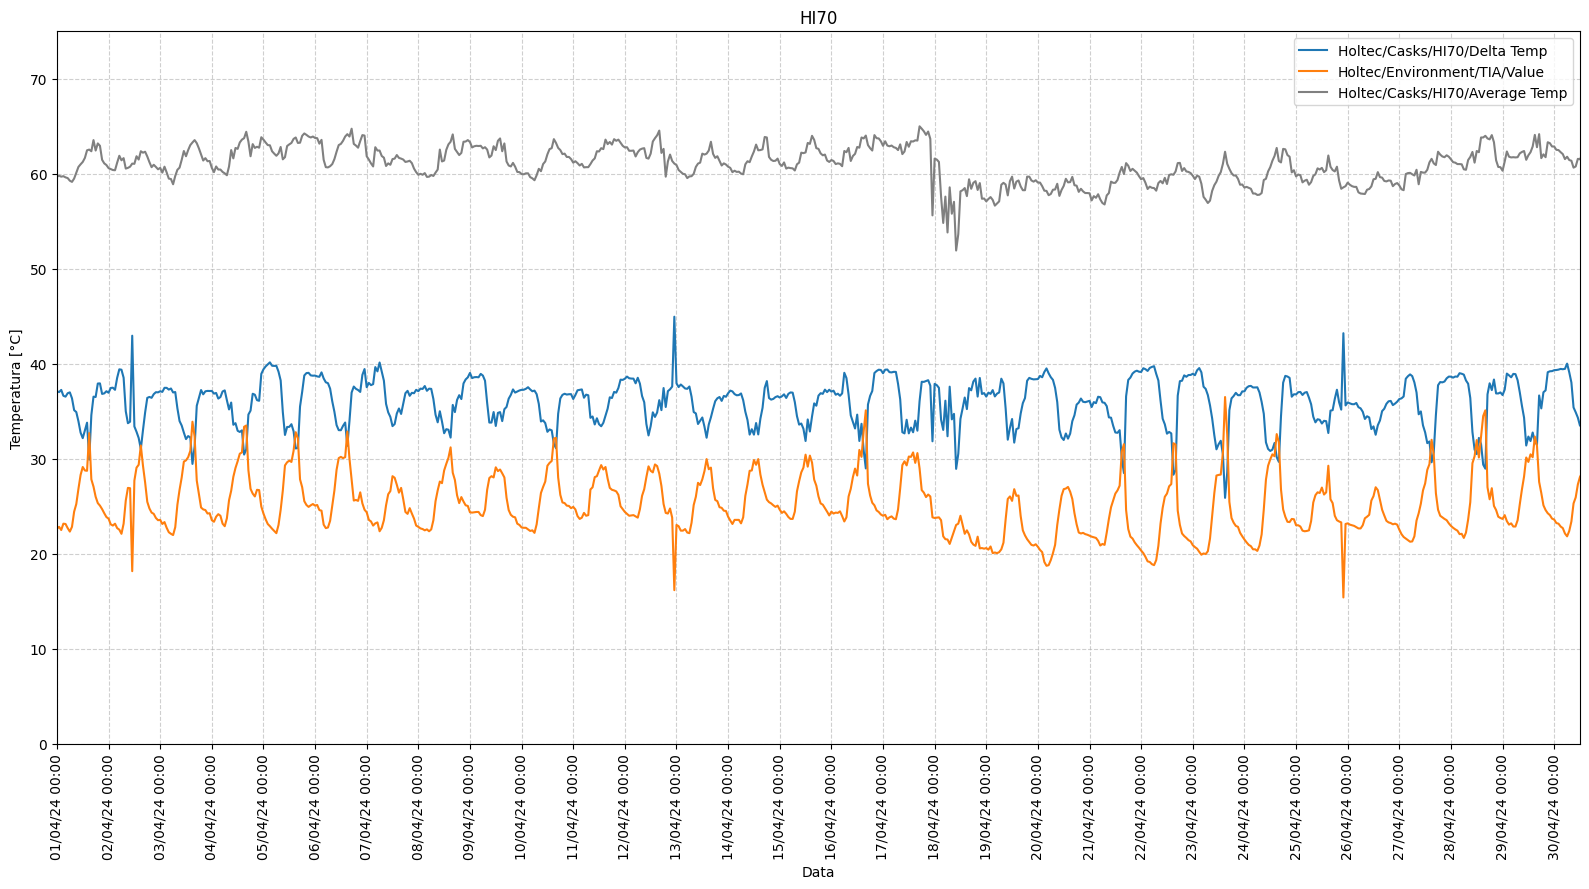

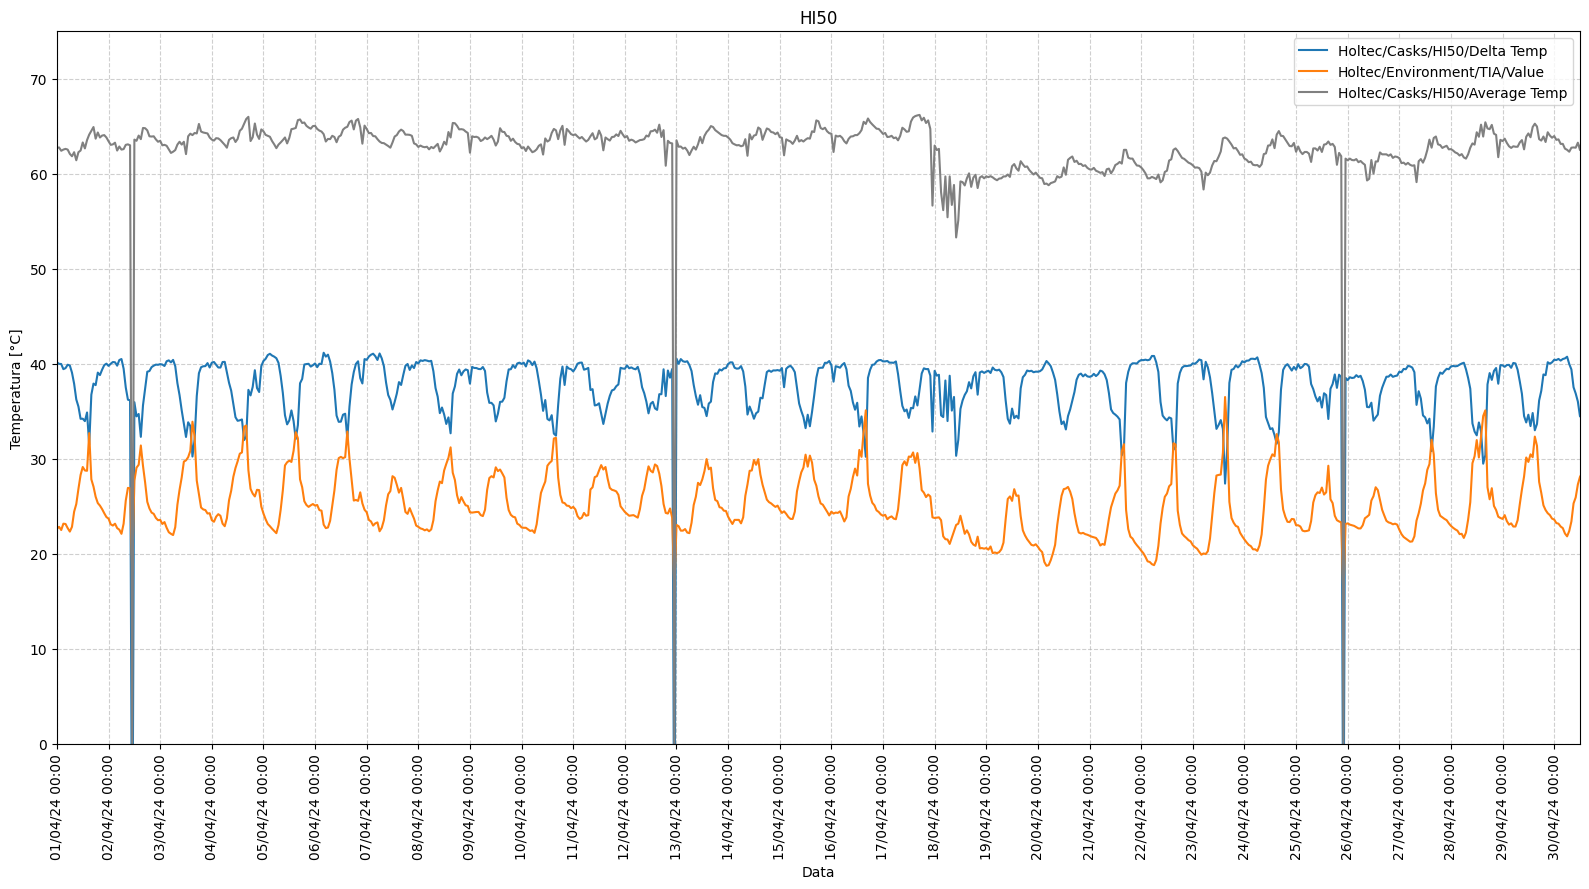

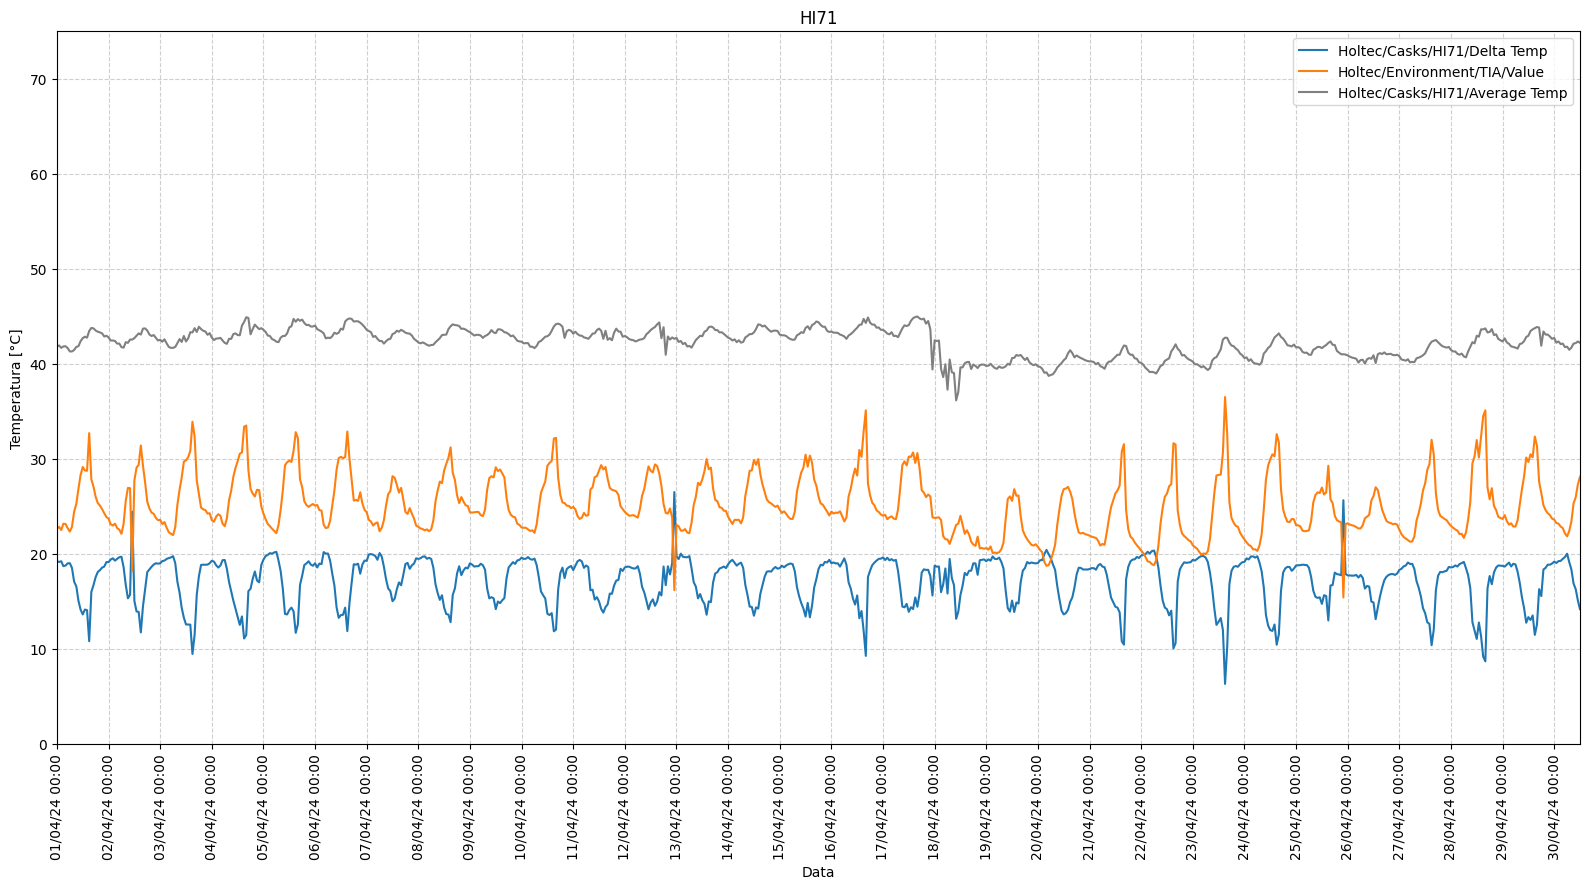

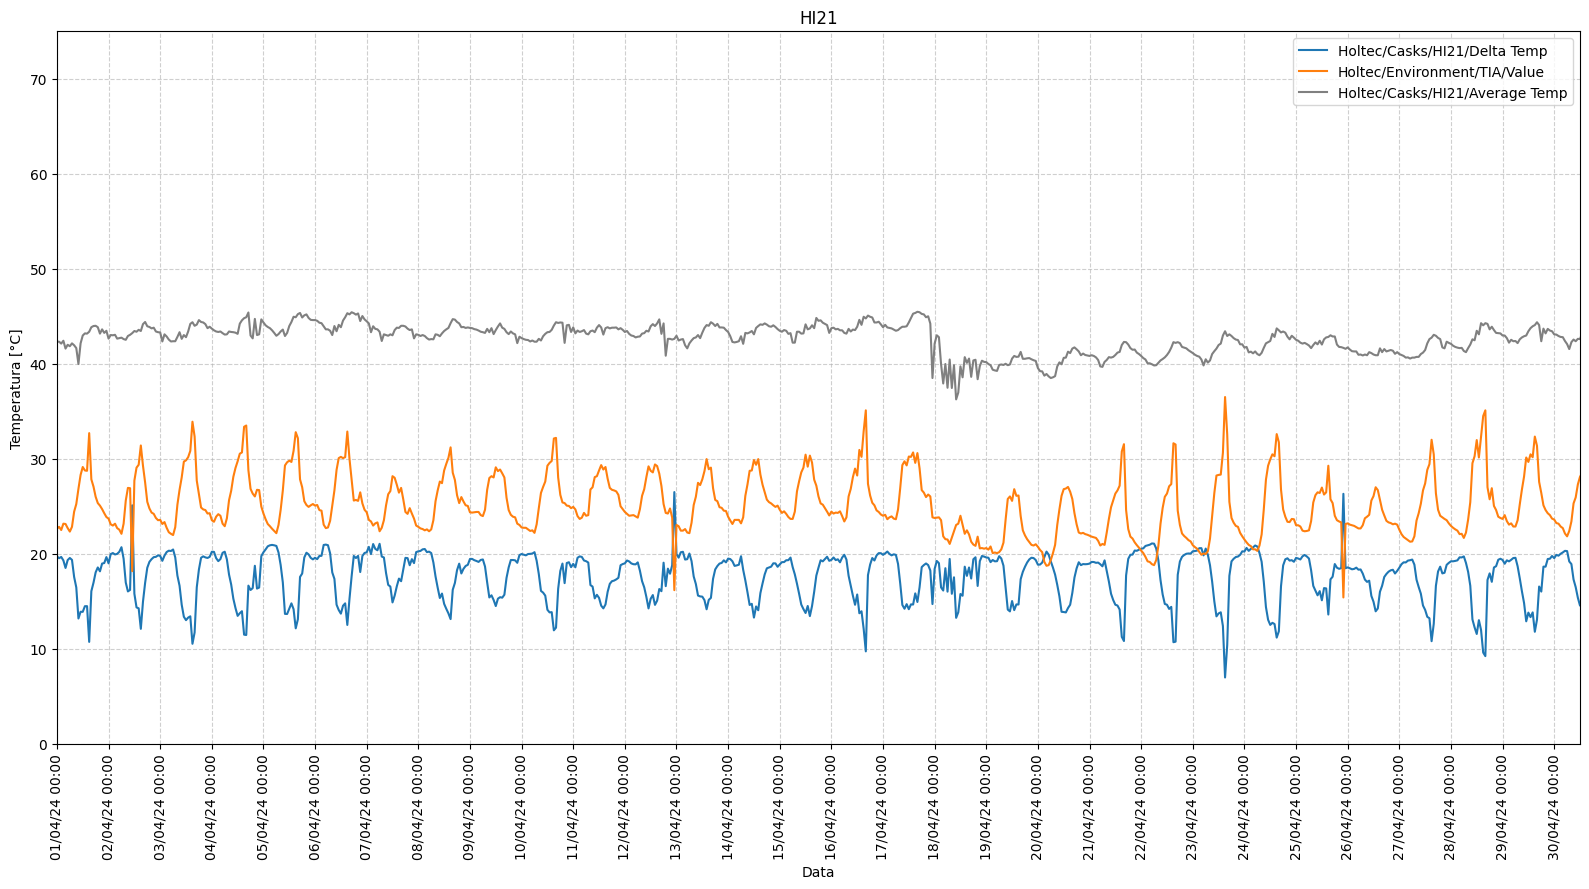

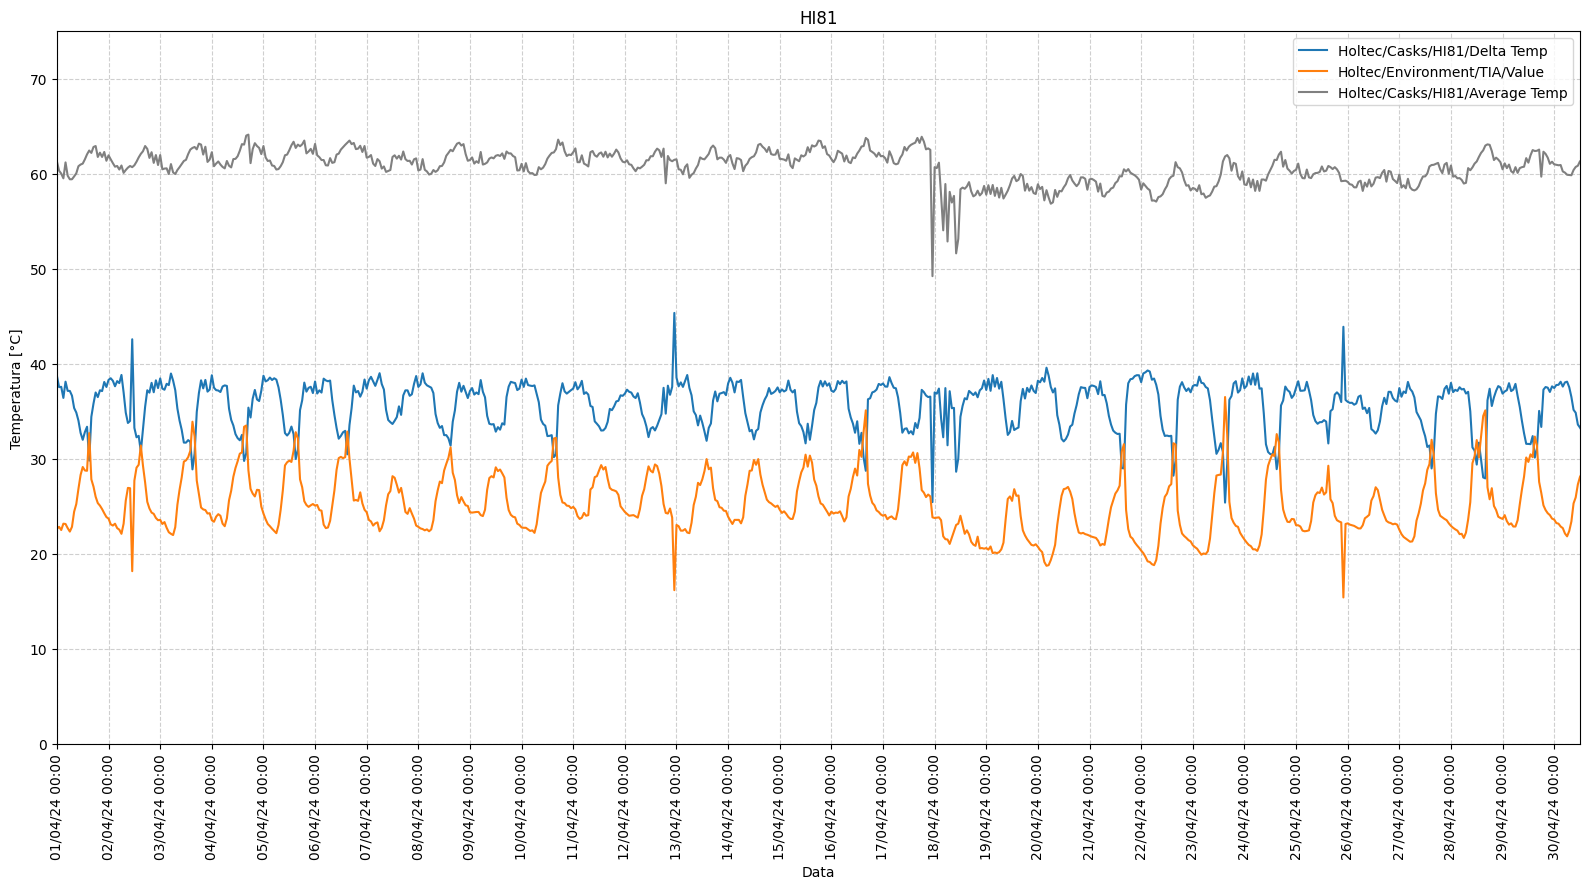

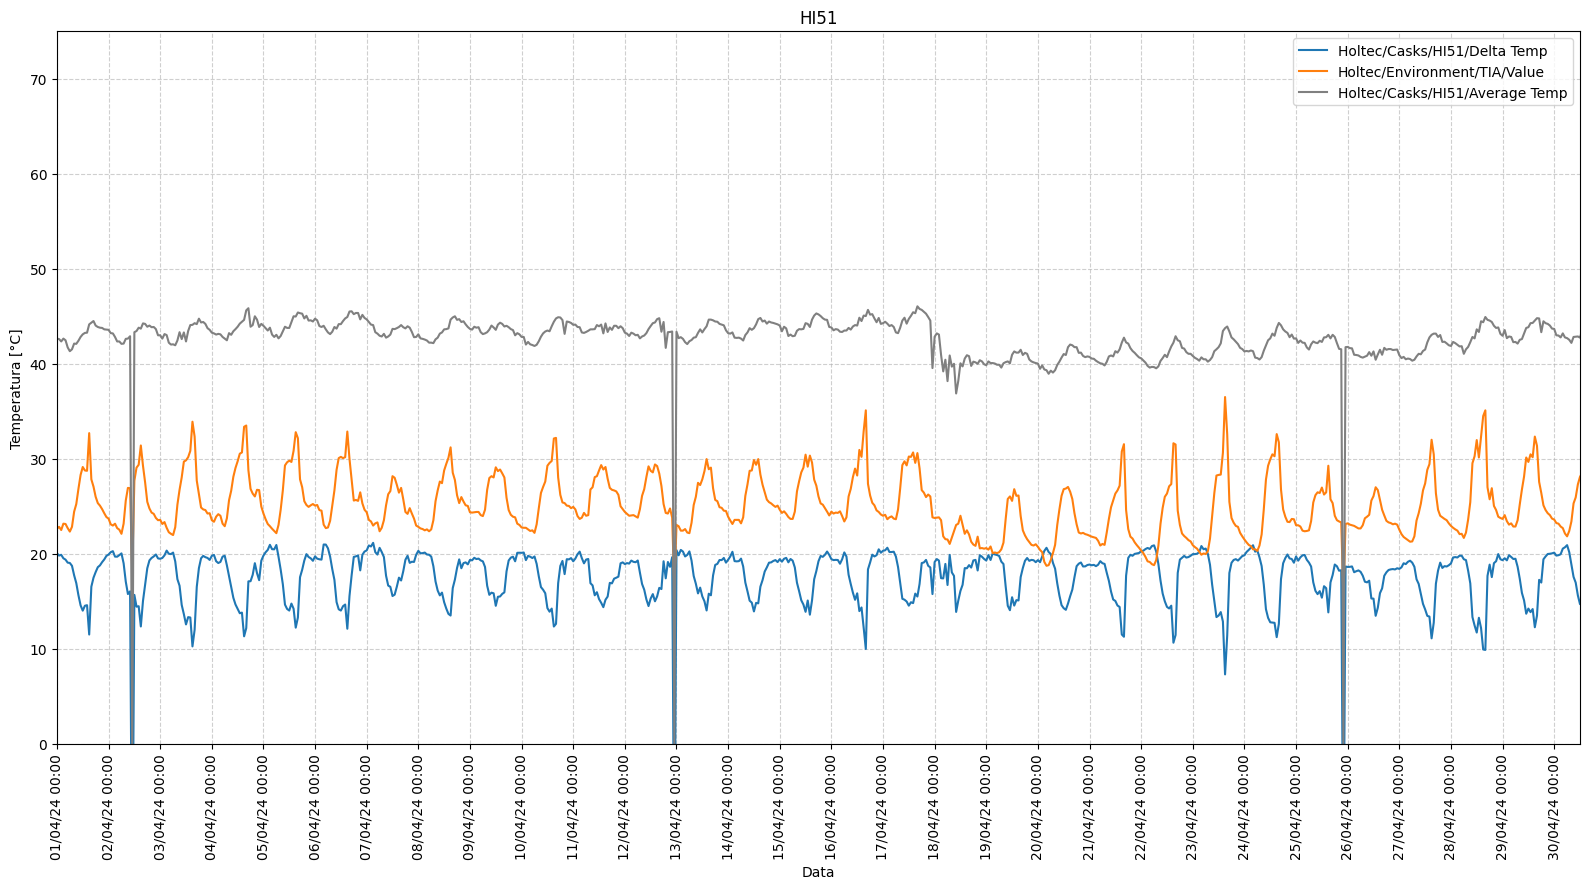

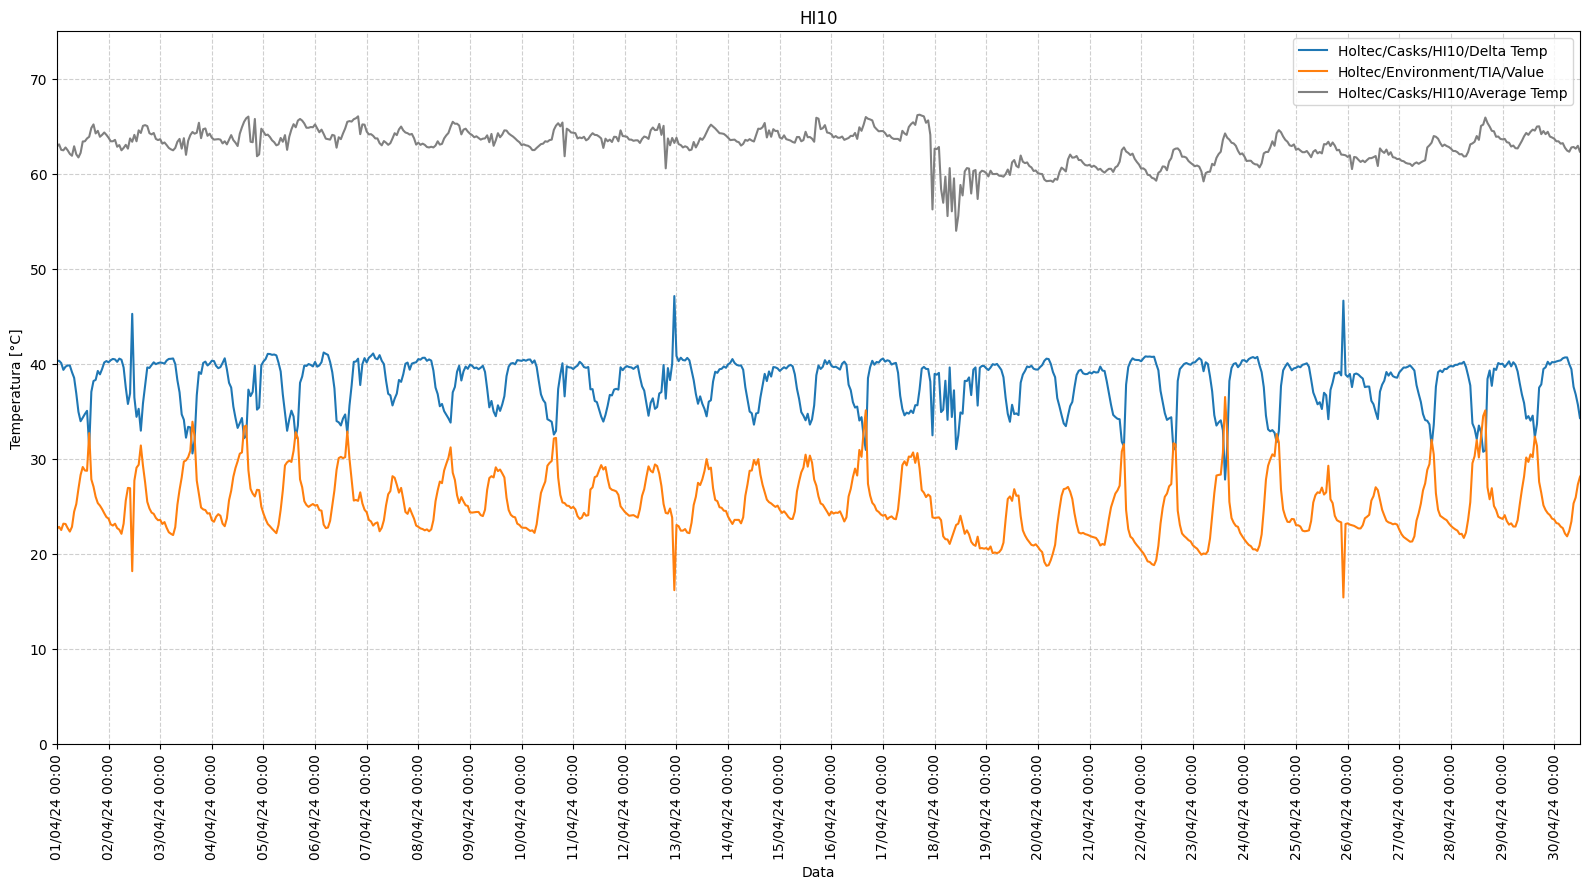

In [53]:
plot_all('./data/Cask Data Monthly.xlsx')